## Preperation

In [1]:
import os
import torch
import random
import numpy as np
import torch.nn as nn
from Model import EEGModel
from Data import EEGDataLoader
from Evaluation import visualizer

In [2]:
DATA_PATH = '.\\RawDataset\\'
CACHE_PATH = '.\\Dataset\\'
MODEL_PATH = '.\\Models\\'

CRITERION = nn.CrossEntropyLoss()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_ARCHITECTURES = ['DeepConvNet', 'ShallowFBCSPNet', 'CTNet', 'Deep4Net']

SUBJECT_COUNT = 15
LEARNING_RATE = 0.01
P_LEARNING_RATE = 0.02
BATCH_SIZE = 8
P_BATCH_SIZE = 16
EPOCH_NUM = 25
P_EPOCH_NUM = 20
RANDOM_SEED = 42
SPLIT = (0.8, 0.1, 0.1)

In [3]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

## DataLoading

Target Classes: ['Elbow Flexion', 'Elbow Extension', 'Supination', 'Pronation', 'Hand Open', 'Hand Close', 'Rest']


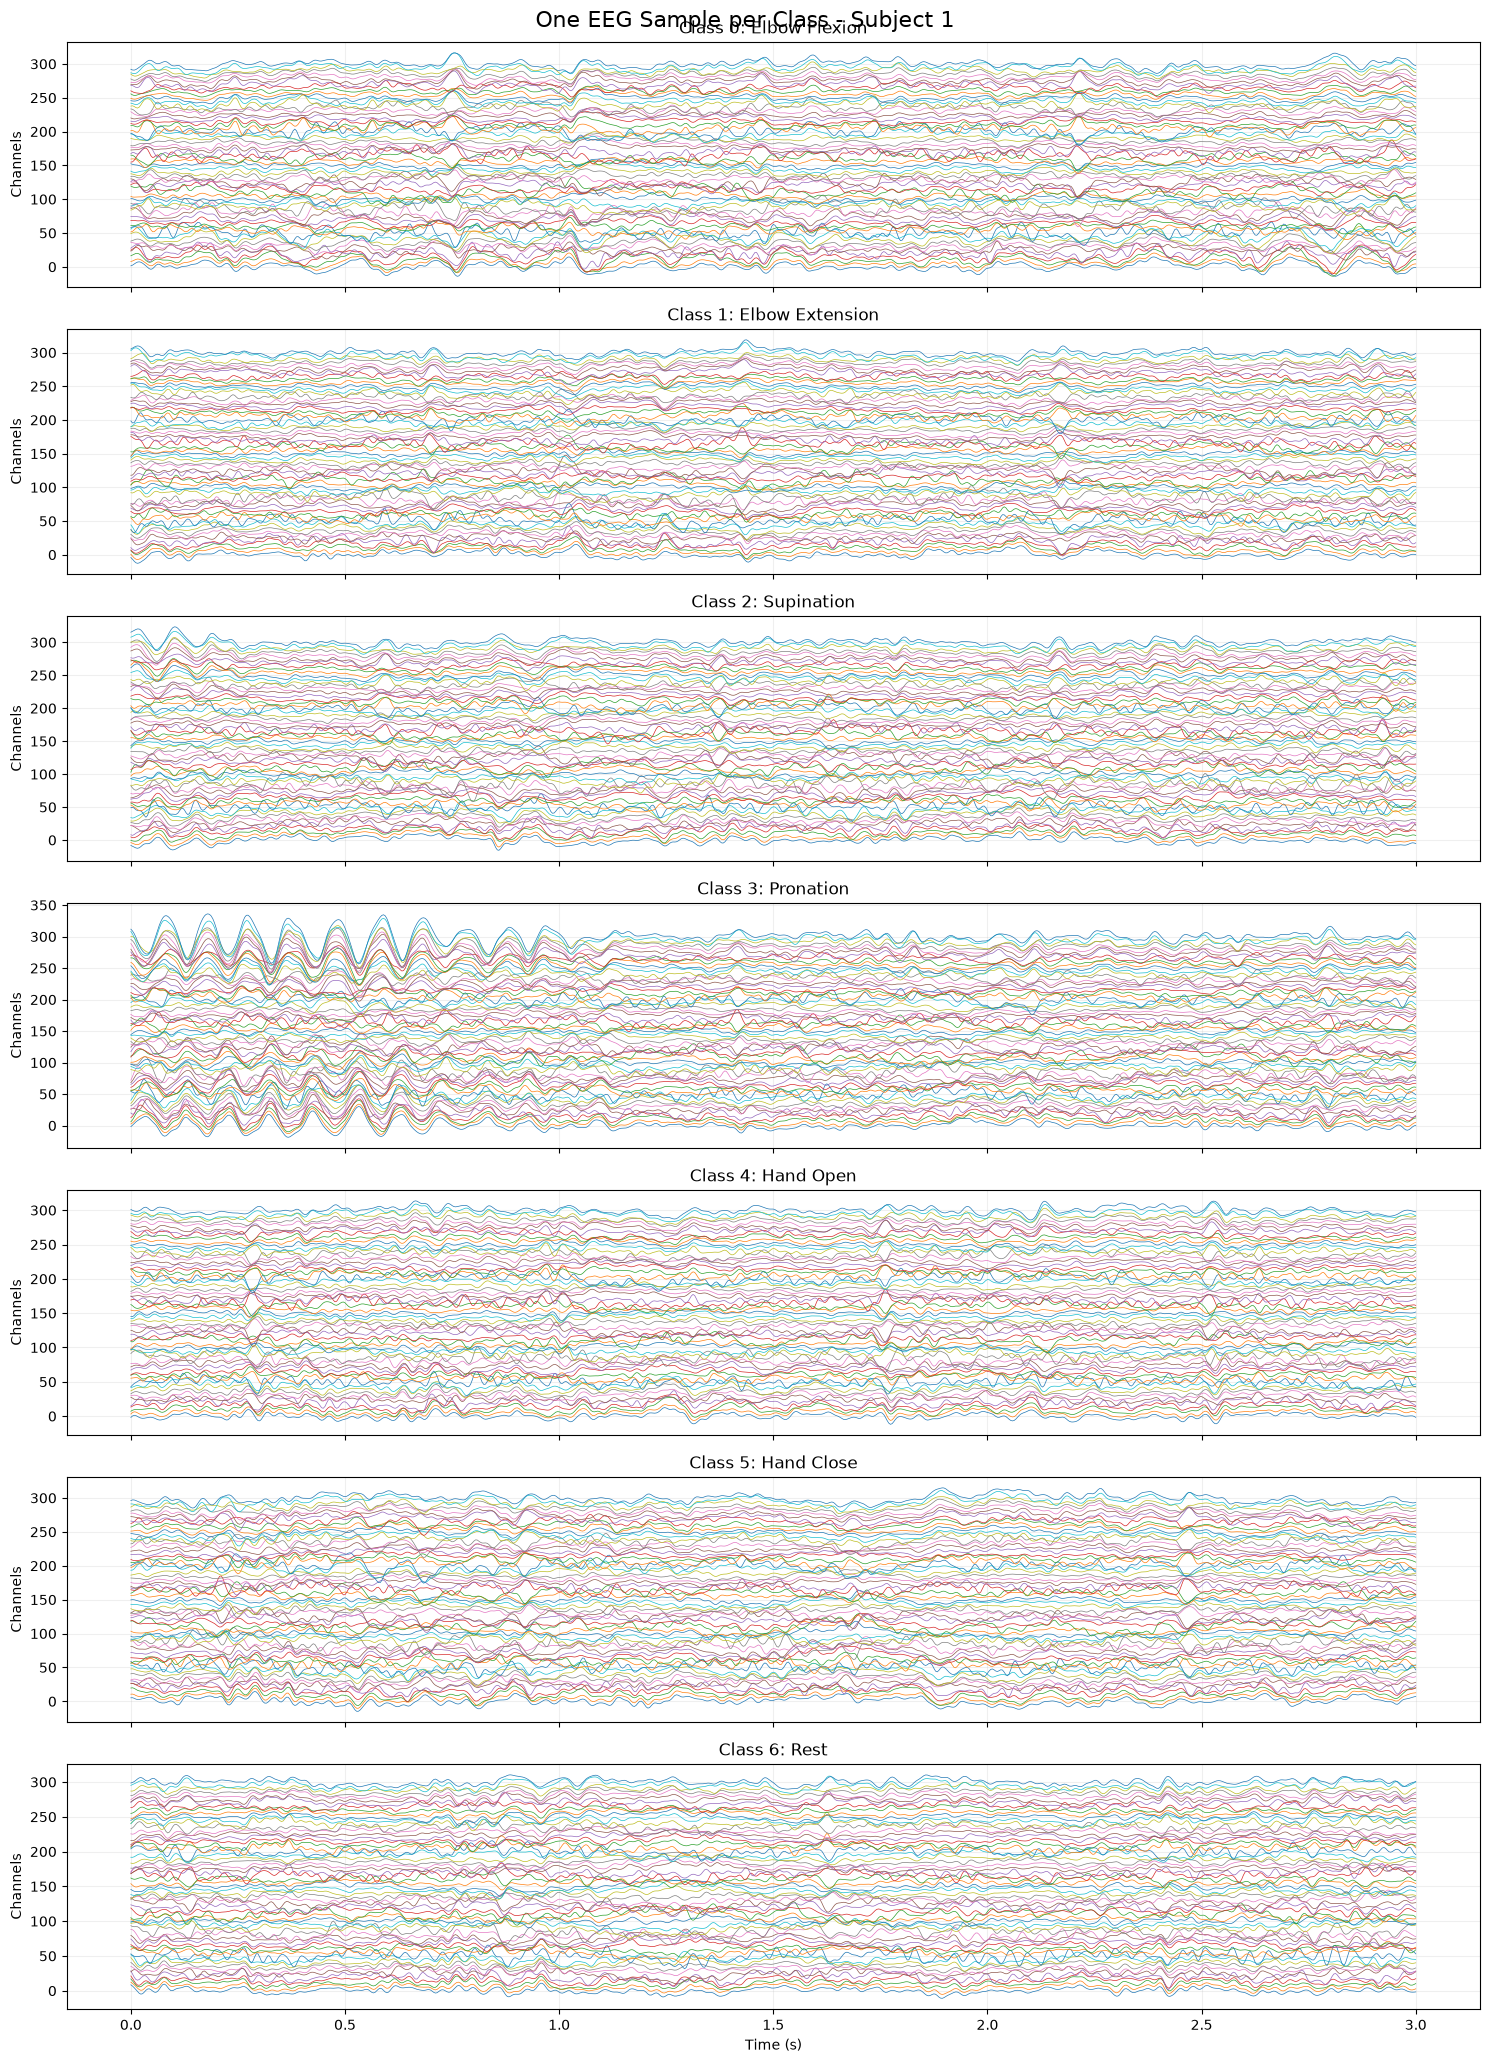

In [4]:
data_loader_factory = EEGDataLoader(
    data_path=DATA_PATH, 
    cache_path=CACHE_PATH, 
    batch_size=BATCH_SIZE,
    split_ratios=SPLIT
)

classes = data_loader_factory.get_class_names()
print(f"Target Classes: {classes}")
visualizer.visualize_one_sample_per_label(
    data_loader_factory,
    subject=1
)

## Basic Training 


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 8, 61, 769]             512
       BatchNorm2d-2           [-1, 8, 61, 769]              16
            Conv2d-3           [-1, 16, 1, 769]             976
       BatchNorm2d-4           [-1, 16, 1, 769]              32
               ELU-5           [-1, 16, 1, 769]               0
         AvgPool2d-6           [-1, 16, 1, 192]               0
           Dropout-7           [-1, 16, 1, 192]               0
            Conv2d-8           [-1, 16, 1, 192]             256
            Conv2d-9           [-1, 16, 1, 192]             256
      BatchNorm2d-10           [-1, 16, 1, 192]              32
              ELU-11           [-1, 16, 1, 192]               0
   

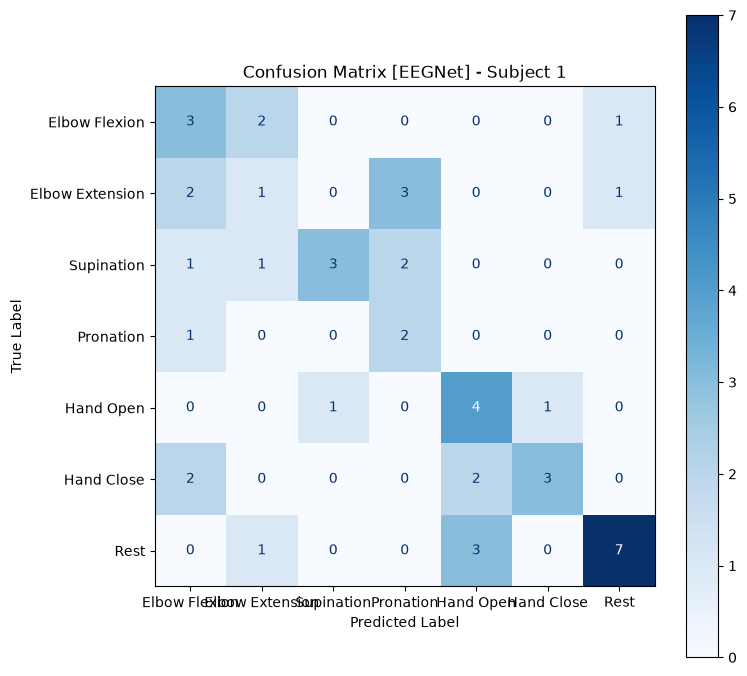

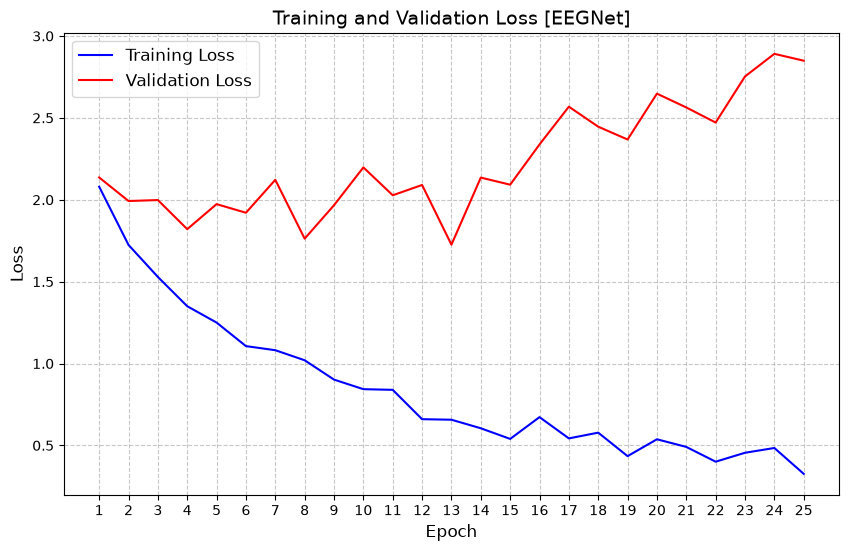

Selected Architecture: DeepConvNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 25, 61, 760]             250
            Conv2d-2           [-1, 25, 1, 760]          38,125
       BatchNorm2d-3           [-1, 25, 1, 760]              50
               ELU-4           [-1, 25, 1, 760]               0
         MaxPool2d-5           [-1, 25, 1, 253]               0
           Dropout-6           [-1, 25, 1, 253]               0
            Conv2d-7           [-1, 50, 1, 244]          12,500
       BatchNorm2d-8           [-1, 50, 1, 244]             100
               ELU-9           [-1, 50, 1, 244]               0
        MaxPool2d-10            [-1, 50, 1, 81]               0
          Dropout-11            [-1, 50, 1, 81]               0
           Conv2d-12           [-1, 100, 1, 72]          50,000
      BatchNorm2d-13           [-1, 100, 1, 72]             200
    

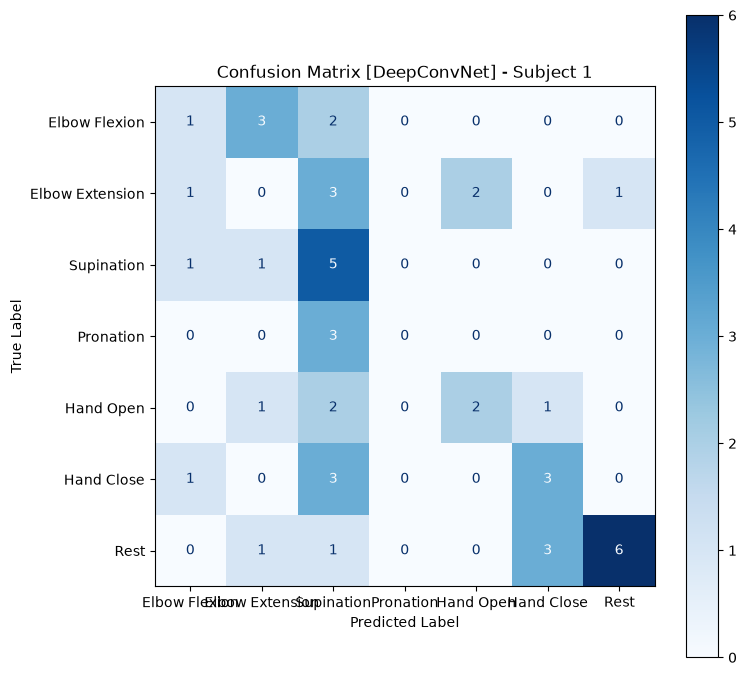

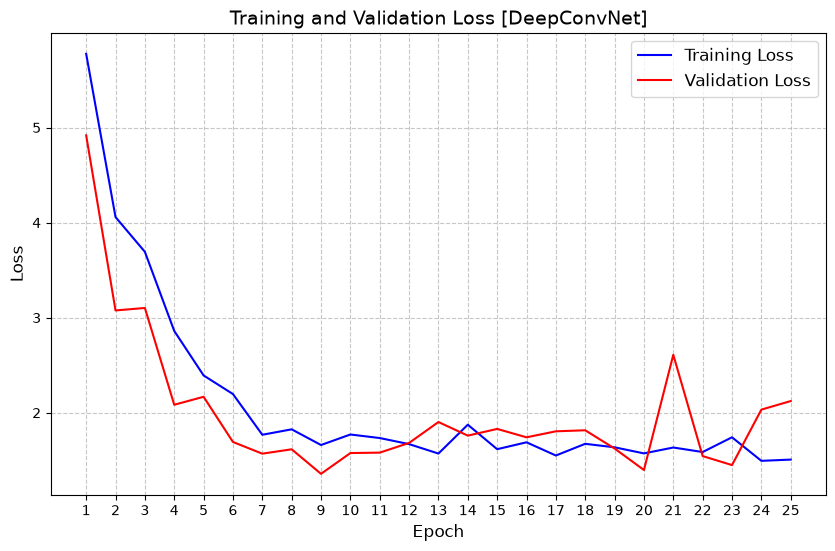

Selected Architecture: ShallowFBCSPNet
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 40, 61, 745]           1,000
            Conv2d-2           [-1, 40, 1, 745]          97,600
       BatchNorm2d-3           [-1, 40, 1, 745]              80
        Expression-4           [-1, 40, 1, 745]               0
         AvgPool2d-5            [-1, 40, 1, 45]               0
        Expression-6            [-1, 40, 1, 45]               0
           Dropout-7            [-1, 40, 1, 45]               0
           Flatten-8                 [-1, 1800]               0
            Linear-9                    [-1, 7]          12,607
Total params: 111,287
Trainable params: 111,287
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 14.61
Params size (MB): 0.42
Estimated Total Size (MB): 15.21
--

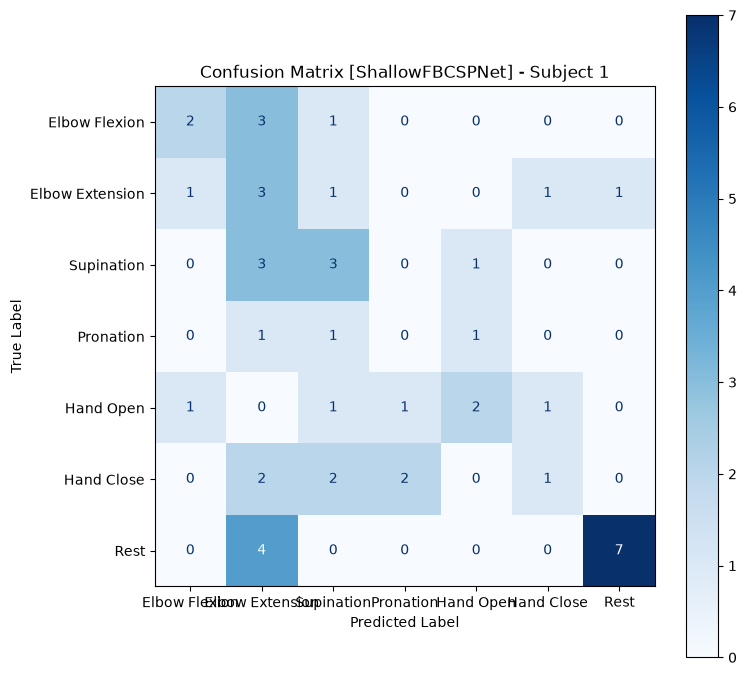

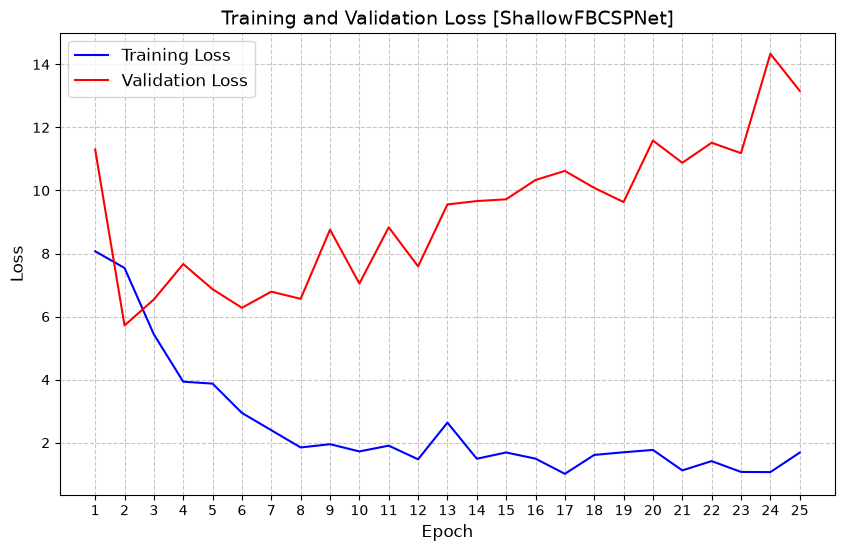

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    visualizer.plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    visualizer.plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")

## Pretraining


------ Setting up training for ALL Subjects ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Loading Subject 9 from cache...
Normalizing data based on training set statistics...
Loading Subject 10 from cache...
Normalizing data based on training set statistics...
Loading Subject 11 from cache...
Normalizing data based on training set statistics...
Loading Sub

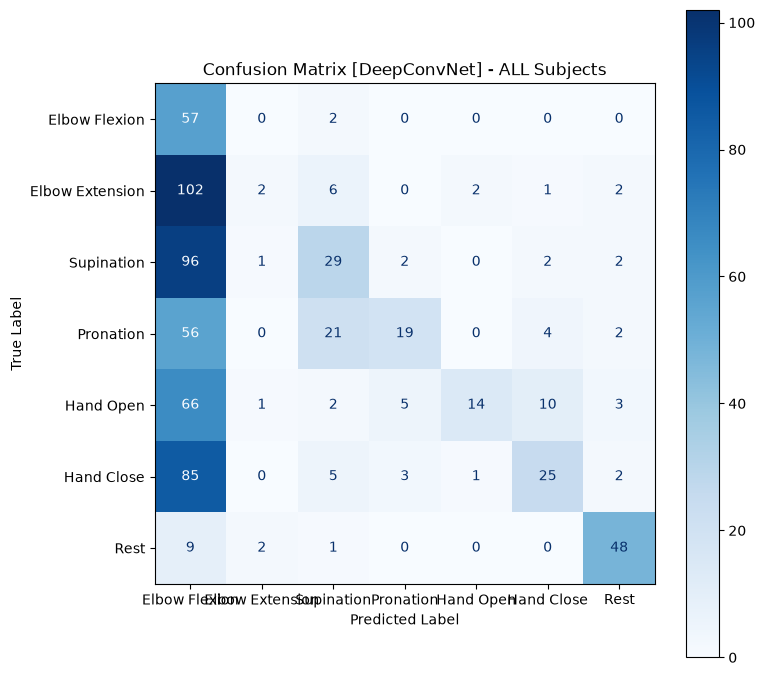

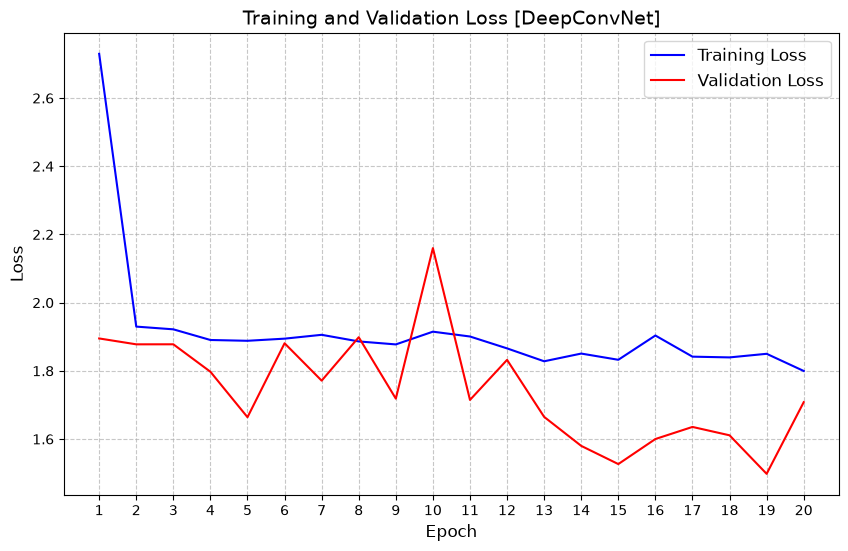

Selected Architecture: ShallowFBCSPNet
Epoch#1 ==== train acc: 30.1716, train loss: 5.6713 ==== val acc: 28.2609, val loss: 2.3593
Epoch#2 ==== train acc: 42.9088, train loss: 1.9777 ==== val acc: 32.4638, val loss: 1.6703
Epoch#3 ==== train acc: 41.9151, train loss: 1.7479 ==== val acc: 34.4928, val loss: 1.6930
Epoch#4 ==== train acc: 42.7100, train loss: 1.6709 ==== val acc: 33.1884, val loss: 1.7292
Epoch#5 ==== train acc: 45.6007, train loss: 1.6746 ==== val acc: 41.5942, val loss: 1.5996
Epoch#6 ==== train acc: 44.1915, train loss: 1.7242 ==== val acc: 32.1739, val loss: 1.7755
Epoch#7 ==== train acc: 44.2999, train loss: 1.7460 ==== val acc: 39.5652, val loss: 1.5965
Epoch#8 ==== train acc: 46.3234, train loss: 1.7511 ==== val acc: 39.4203, val loss: 1.6504
Epoch#9 ==== train acc: 43.9747, train loss: 1.7359 ==== val acc: 37.2464, val loss: 1.6816
Epoch#10 ==== train acc: 42.4932, train loss: 1.7968 ==== val acc: 33.4783, val loss: 1.8626
Epoch#11 ==== train acc: 38.8437, train 

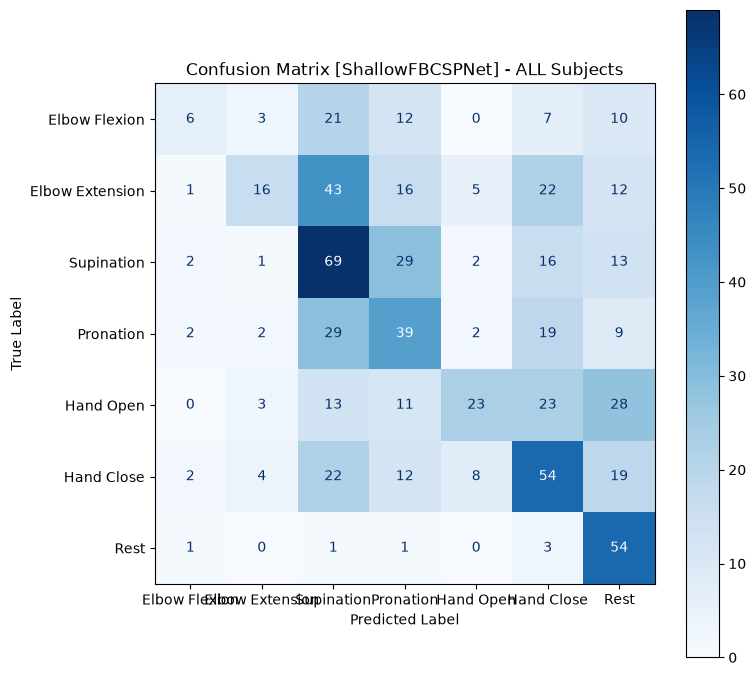

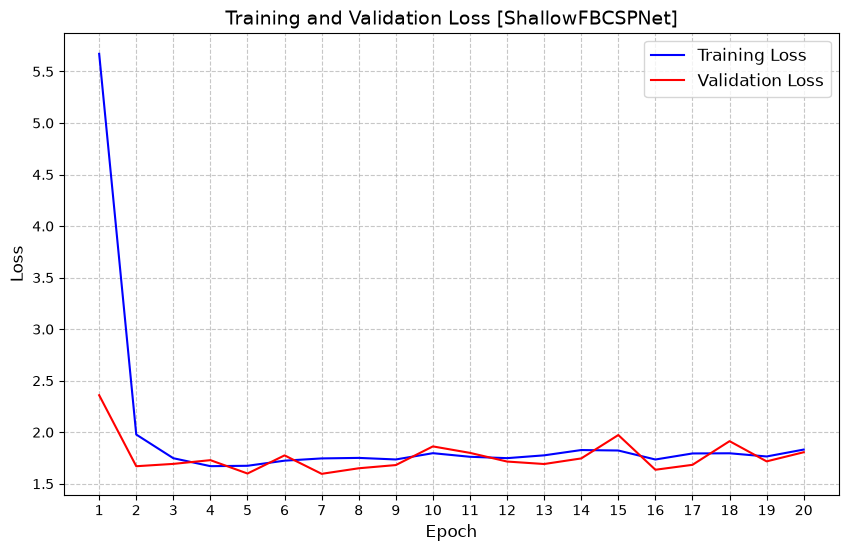

Selected Architecture: CTNet
Epoch#1 ==== train acc: 34.1283, train loss: 2.1423 ==== val acc: 27.3913, val loss: 1.8046
Epoch#2 ==== train acc: 35.7724, train loss: 1.7030 ==== val acc: 30.8696, val loss: 1.8542
Epoch#3 ==== train acc: 41.3008, train loss: 1.6487 ==== val acc: 34.3478, val loss: 1.7947
Epoch#4 ==== train acc: 39.1509, train loss: 1.6276 ==== val acc: 36.8116, val loss: 1.7624
Epoch#5 ==== train acc: 48.2204, train loss: 1.5878 ==== val acc: 36.8116, val loss: 1.6251
Epoch#6 ==== train acc: 46.4137, train loss: 1.5420 ==== val acc: 36.2319, val loss: 1.8032
Epoch#7 ==== train acc: 46.6667, train loss: 1.5366 ==== val acc: 34.3478, val loss: 1.7683
Epoch#8 ==== train acc: 46.7209, train loss: 1.5139 ==== val acc: 34.0580, val loss: 1.7648
Epoch#9 ==== train acc: 47.3171, train loss: 1.4742 ==== val acc: 33.1884, val loss: 1.7441
Epoch#10 ==== train acc: 54.8509, train loss: 1.4334 ==== val acc: 37.2464, val loss: 1.7229
Epoch#11 ==== train acc: 50.6052, train loss: 1.41

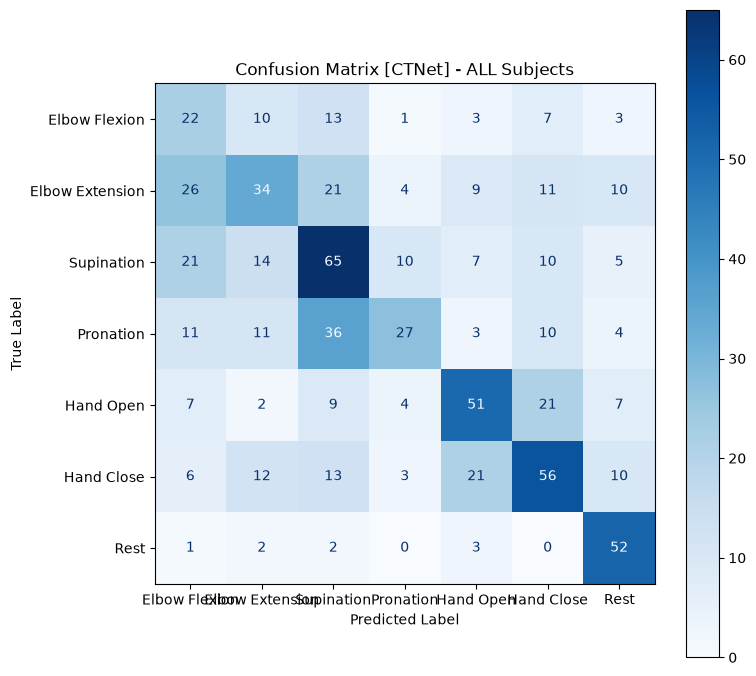

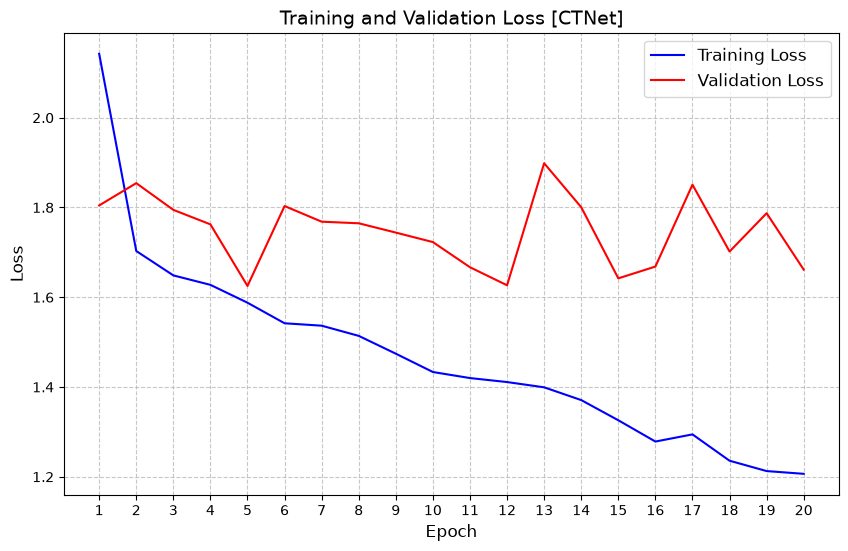

Selected Architecture: Deep4Net
Epoch#1 ==== train acc: 21.9332, train loss: 2.0502 ==== val acc: 21.1594, val loss: 1.8573
Epoch#2 ==== train acc: 26.4137, train loss: 1.8231 ==== val acc: 21.4493, val loss: 1.9186
Epoch#3 ==== train acc: 28.3469, train loss: 1.7465 ==== val acc: 25.9420, val loss: 1.7257
Epoch#4 ==== train acc: 33.0262, train loss: 1.7243 ==== val acc: 24.3478, val loss: 1.8413
Epoch#5 ==== train acc: 33.2972, train loss: 1.6969 ==== val acc: 26.5217, val loss: 1.7842
Epoch#6 ==== train acc: 35.9169, train loss: 1.6812 ==== val acc: 28.4058, val loss: 1.6971
Epoch#7 ==== train acc: 33.7308, train loss: 1.6903 ==== val acc: 27.1014, val loss: 1.8290
Epoch#8 ==== train acc: 34.7787, train loss: 1.6759 ==== val acc: 34.6377, val loss: 1.6438
Epoch#9 ==== train acc: 39.7651, train loss: 1.6684 ==== val acc: 31.1594, val loss: 1.6950
Epoch#10 ==== train acc: 37.1454, train loss: 1.6538 ==== val acc: 29.1304, val loss: 1.6834
Epoch#11 ==== train acc: 35.4291, train loss: 1

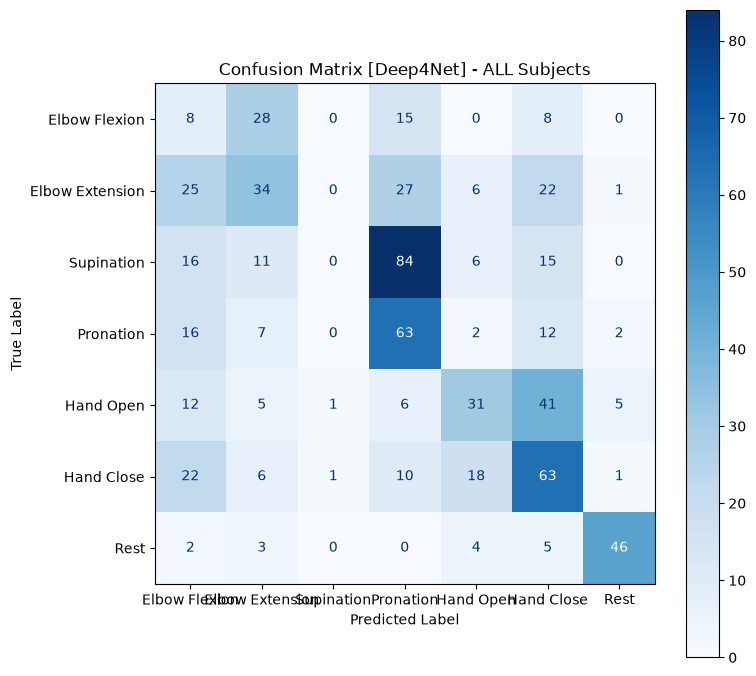

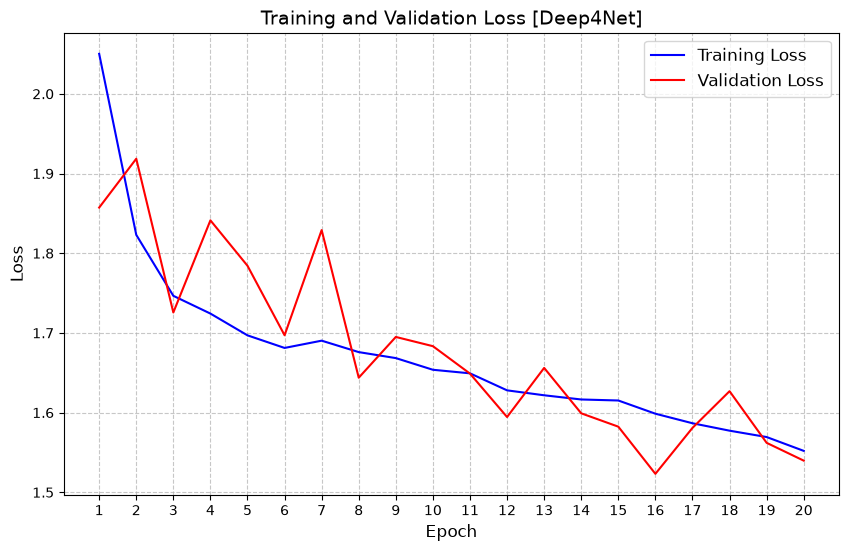

Selected Architecture: EEGConformer


c:\Users\Diego\Documents\GitHub\EEG_Decoder_Robustness\Model.py:178: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


Epoch#1 ==== train acc: 16.5131, train loss: 117.1075 ==== val acc: 10.5797, val loss: 45.6340
Epoch#2 ==== train acc: 27.1003, train loss: 36.7780 ==== val acc: 24.2029, val loss: 5.4895
Epoch#3 ==== train acc: 28.5998, train loss: 12.6592 ==== val acc: 24.2029, val loss: 4.3822
Epoch#4 ==== train acc: 28.4553, train loss: 7.3038 ==== val acc: 23.6232, val loss: 3.1368
Epoch#5 ==== train acc: 33.2611, train loss: 4.7657 ==== val acc: 27.8261, val loss: 2.2260
Epoch#6 ==== train acc: 32.0867, train loss: 3.3663 ==== val acc: 25.0725, val loss: 2.0827
Epoch#7 ==== train acc: 32.7733, train loss: 2.7025 ==== val acc: 25.6522, val loss: 1.9392
Epoch#8 ==== train acc: 35.9169, train loss: 2.3895 ==== val acc: 27.8261, val loss: 1.8556
Epoch#9 ==== train acc: 36.4589, train loss: 2.2728 ==== val acc: 25.9420, val loss: 1.8643
Epoch#10 ==== train acc: 22.5836, train loss: 2.2292 ==== val acc: 24.2029, val loss: 2.2365
Epoch#11 ==== train acc: 34.4173, train loss: 2.3082 ==== val acc: 24.2029

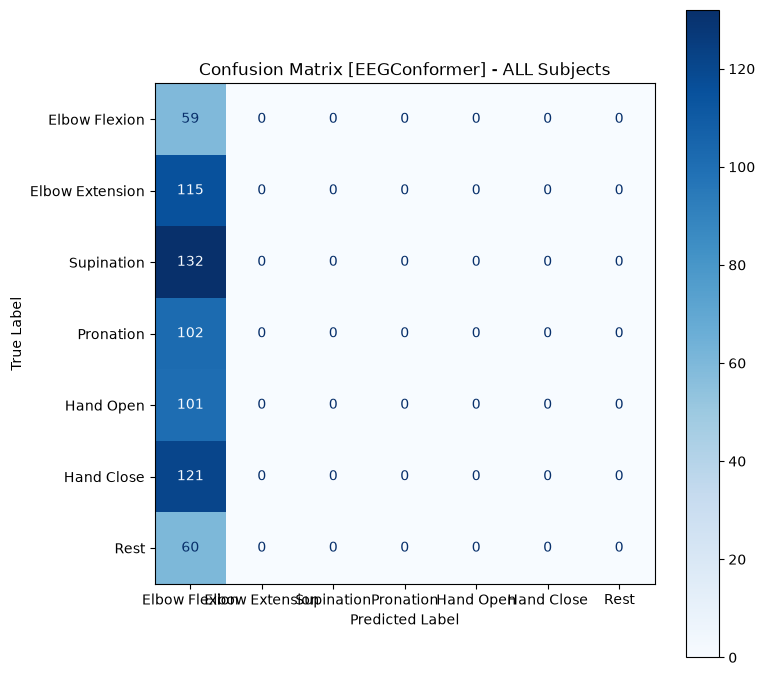

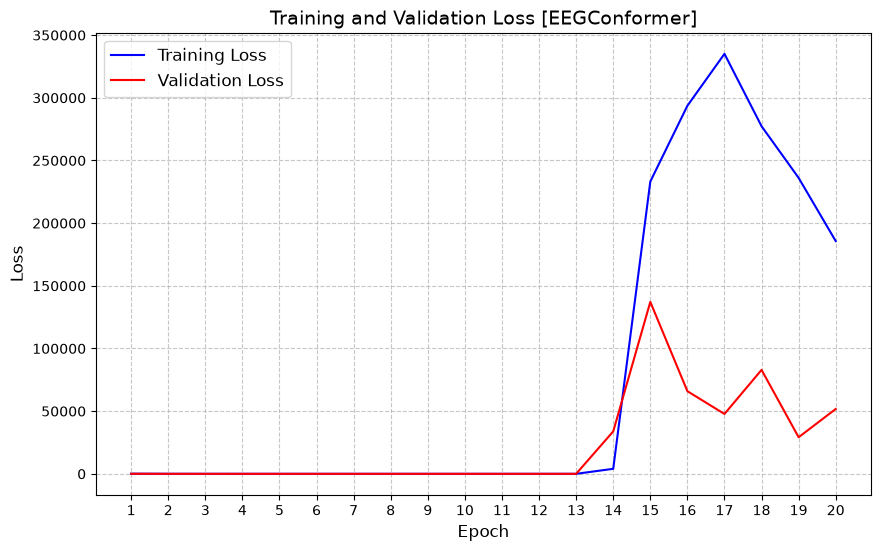

Finished training.


In [ ]:
print(f"\n------ Setting up training for ALL Subjects ------")
subjects=[i + 1 for i in range(SUBJECT_COUNT)]
full_train_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED)
full_val_loader = data_loader_factory.combined_dataloaders(subjects=subjects, batch_size=P_BATCH_SIZE, random_seed=RANDOM_SEED, train=False)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=P_LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    model.model_summary()
    train_loss, val_loss = [], []
    model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')

    for epoch in range(P_EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(full_train_loader, full_val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(full_train_loader)
        val_acc = model.evaluate_accuracy(full_val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

    model.save_model(model_path)

    print('\nModel Final Accuracy:')
    print('\tTrain:', model.evaluate_accuracy(full_train_loader))
    print('\tValidation:', model.evaluate_accuracy(full_val_loader))

    visualizer.plot_confusion_matrix(
        model=model,
        data_loader=full_val_loader,
        class_names=classes,
        title=f'Confusion Matrix [{architecture}] - ALL Subjects'
    )
    visualizer.plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training.")

## Fine-tunning

#################### Selected Architecture: DeepConvNet ####################
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Subject #1:	Test Acc: 55.3191	Validation Acc: 60.8696
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Test Acc: 55.3191	Validation Acc: 52.1739
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Test Acc: 87.2340	Validation Acc: 100.0000
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Test Acc: 91.4894	Validation Acc: 97.8261
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Test Acc: 53.1915	Validation Acc: 58.6957
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Test Acc: 53.1915	Validation Acc: 63.0435
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Sub

c:\Users\Diego\Documents\GitHub\EEG_Decoder_Robustness\Model.py:178: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  dropout=0.5,


Subject #1:	Test Acc: 12.7660	Validation Acc: 17.3913
Loading Subject 2 from cache...
Normalizing data based on training set statistics...
Subject #2:	Test Acc: 12.7660	Validation Acc: 15.2174
Loading Subject 3 from cache...
Normalizing data based on training set statistics...
Subject #3:	Test Acc: 12.7660	Validation Acc: 19.5652
Loading Subject 4 from cache...
Normalizing data based on training set statistics...
Subject #4:	Test Acc: 8.5106	Validation Acc: 21.7391
Loading Subject 5 from cache...
Normalizing data based on training set statistics...
Subject #5:	Test Acc: 12.7660	Validation Acc: 21.7391
Loading Subject 6 from cache...
Normalizing data based on training set statistics...
Subject #6:	Test Acc: 12.7660	Validation Acc: 15.2174
Loading Subject 7 from cache...
Normalizing data based on training set statistics...
Subject #7:	Test Acc: 6.3830	Validation Acc: 13.0435
Loading Subject 8 from cache...
Normalizing data based on training set statistics...
Subject #8:	Test Acc: 12.7660

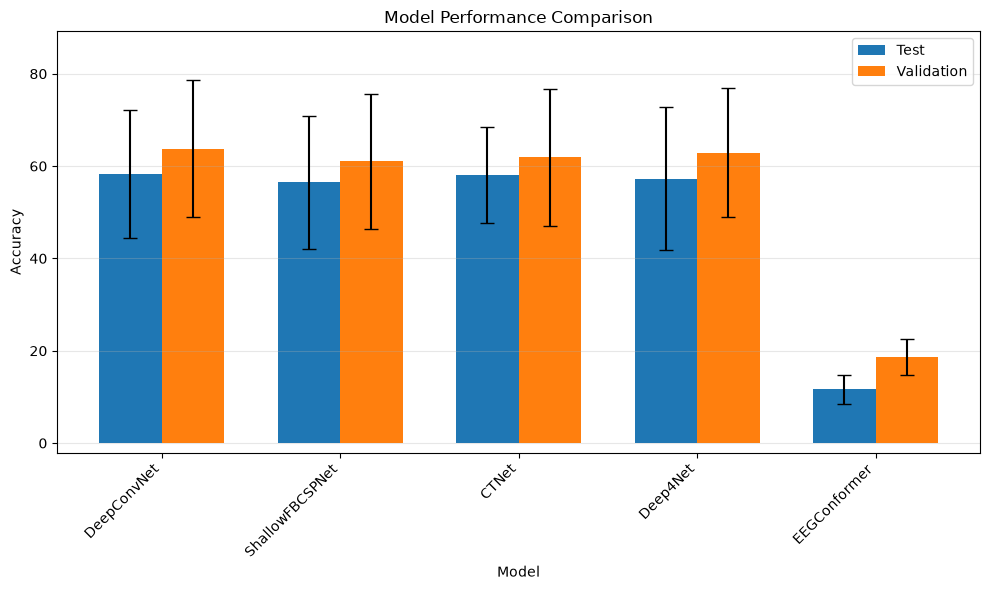

In [ ]:
test_mean, test_var, val_mean, val_var = [], [], [], []
for architecture in MODEL_ARCHITECTURES:
    print('#' * 20, 'Selected Architecture:', architecture, '#' * 20)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    test_accs, val_accs = [], []
    for subject_id in range(1, 1 + SUBJECT_COUNT):
        train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)
        pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
        model.load_model(pretrained_model_path, verbose=False)
        best_val_accuracy = -float('inf')
        best_epoch = 0
        best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')
        for epoch in range(EPOCH_NUM):
            t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
            val_acc = model.evaluate_accuracy(val_loader)
            if val_acc > best_val_accuracy:
                best_val_accuracy = val_acc
                best_epoch = epoch + 1
                model.save_model(best_model_path, verbose=False)
        
        model.load_model(best_model_path, verbose=False)
        test_acc = model.evaluate_accuracy(test_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        test_accs.append(test_acc)
        val_accs.append(val_acc)
        print(f'Subject #{subject_id}:\tTest Acc: {test_acc:.4f}\tValidation Acc: {val_acc:.4f}')
    test_mean.append(np.mean(test_accs))
    test_var.append(np.var(test_accs))
    val_mean.append(np.mean(val_accs))
    val_var.append(np.var(val_accs))
    print('Results for Model Accuracy')
    print(f'Validation: ~N({test_mean[-1]:.3f}, {test_var[-1]:.3f}), Test: ~N({val_mean[-1]:.3f}, {val_var[-1]:.3f})\n')
visualizer.plot_model_performance(MODEL_ARCHITECTURES, test_mean, test_var, val_mean, val_var)


------ Setting up training for Subject 1 ------
Loading Subject 1 from cache...
Normalizing data based on training set statistics...
Selected Architecture: EEGNet
Model loaded successfully from .\Models\Pretrained\EEGNet_0.02_20.pth
Epoch#1 ==== train acc: 58.5366, train loss: 1.4795 ==== val acc: 39.1304, val loss: 1.5978
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 39.1304% (Epoch 1)
Epoch#2 ==== train acc: 66.3957, train loss: 1.2866 ==== val acc: 41.3043, val loss: 1.5389
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 70.7317, train loss: 1.1276 ==== val acc: 43.4783, val loss: 1.4564
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 43.4783% (Epoch 3)
Epoch#4 ==== train acc: 74.5257, train loss: 0.9796 ==== val acc: 47.8261, val loss: 1.4954
Model

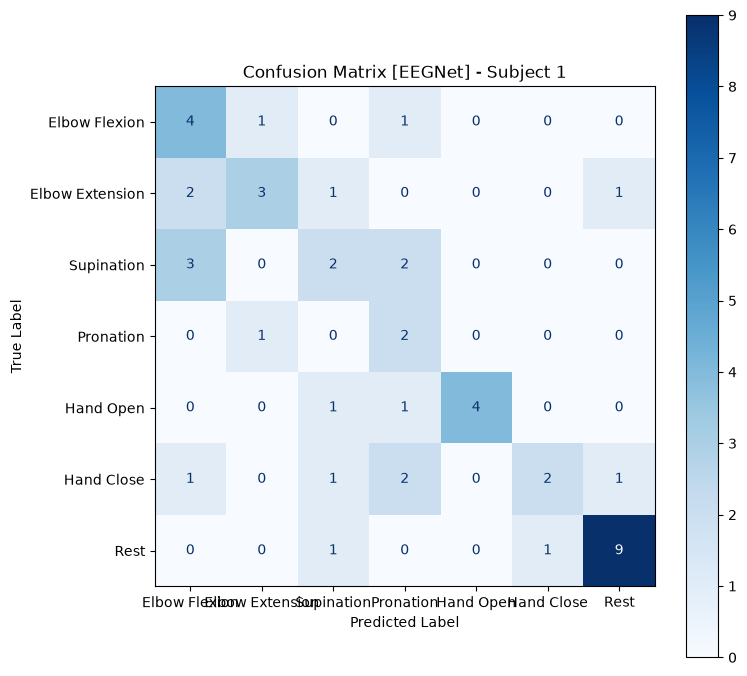

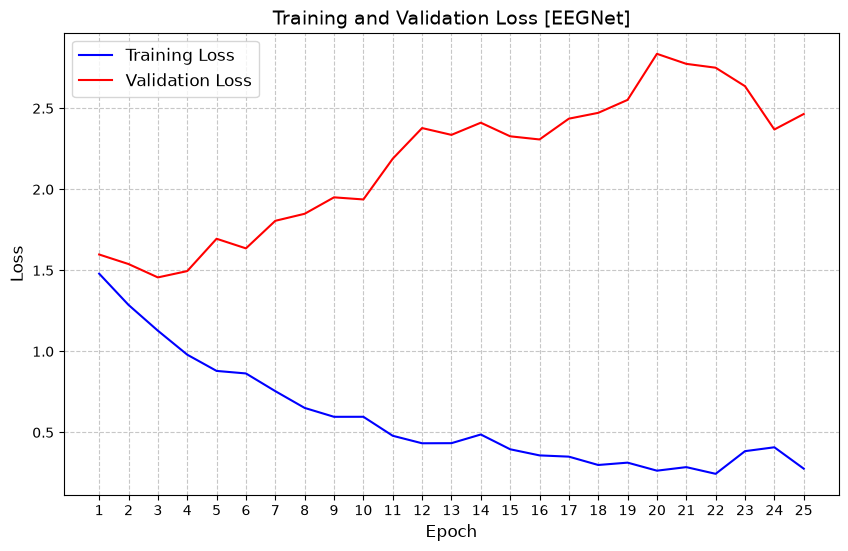

Selected Architecture: DeepConvNet
Model loaded successfully from .\Models\Pretrained\DeepConvNet_0.02_20.pth
Epoch#1 ==== train acc: 46.6125, train loss: 2.0133 ==== val acc: 36.9565, val loss: 1.5558
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 60.4336, train loss: 1.6281 ==== val acc: 50.0000, val loss: 1.3952
Model saved successfully to .\Models\Subject 1\Finetuned_DeepConvNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 50.0000% (Epoch 2)
Epoch#3 ==== train acc: 62.8726, train loss: 1.4632 ==== val acc: 47.8261, val loss: 1.3240
Epoch#4 ==== train acc: 60.7046, train loss: 1.4384 ==== val acc: 39.1304, val loss: 1.6224
Epoch#5 ==== train acc: 65.3117, train loss: 1.3221 ==== val acc: 43.4783, val loss: 1.3448
Epoch#6 ==== train acc: 69.9187, train loss: 1.2272 ==== val acc: 45.6522, val loss: 1.3297
Epoch#7 ==== train acc: 66.6667, train loss: 1.1743 ==== val acc: 

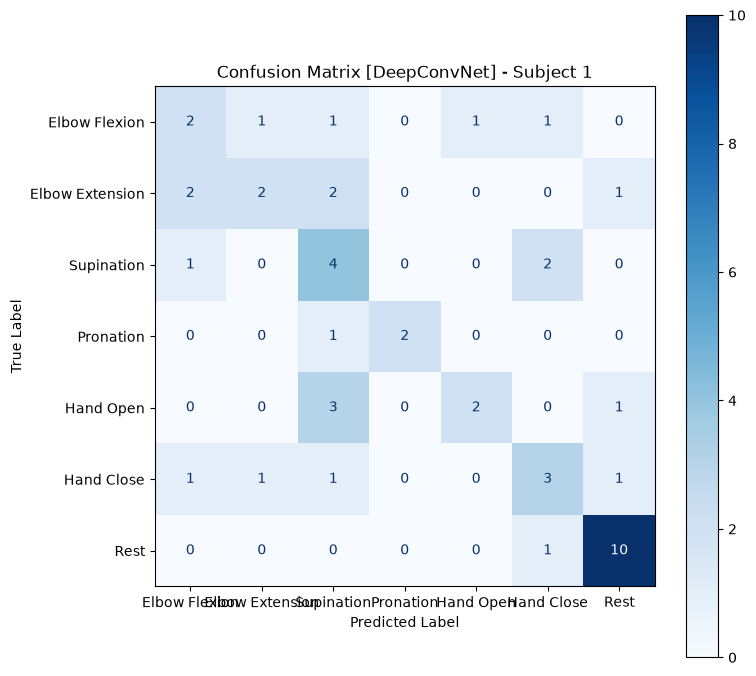

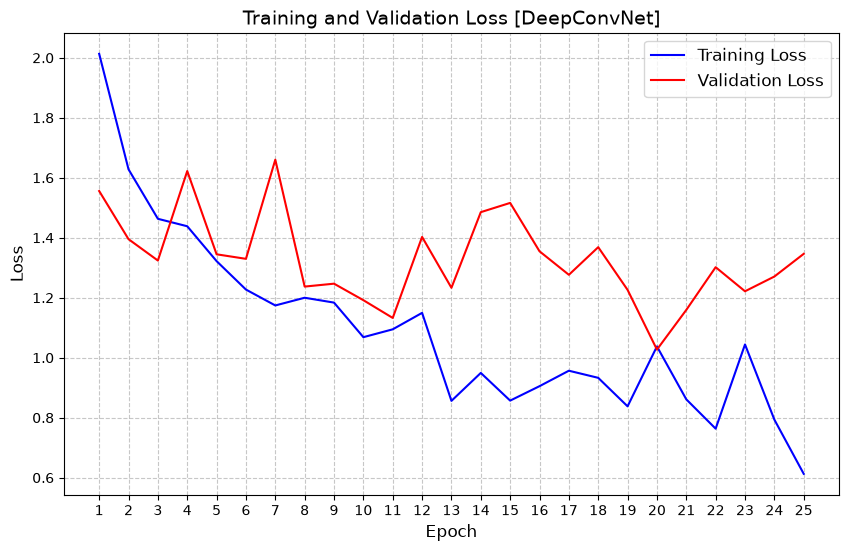

Selected Architecture: ShallowFBCSPNet
Model loaded successfully from .\Models\Pretrained\ShallowFBCSPNet_0.02_20.pth
Epoch#1 ==== train acc: 67.7507, train loss: 1.6376 ==== val acc: 36.9565, val loss: 1.5960
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 73.9837, train loss: 1.3302 ==== val acc: 47.8261, val loss: 1.4361
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 2)
Epoch#3 ==== train acc: 75.8808, train loss: 1.2437 ==== val acc: 45.6522, val loss: 1.5177
Epoch#4 ==== train acc: 77.2358, train loss: 1.0443 ==== val acc: 45.6522, val loss: 1.5878
Epoch#5 ==== train acc: 92.4119, train loss: 0.8092 ==== val acc: 56.5217, val loss: 1.4981
Model saved successfully to .\Models\Subject 1\Finetuned_ShallowFBCSPNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 56.5217% (Epoch 5)
Ep

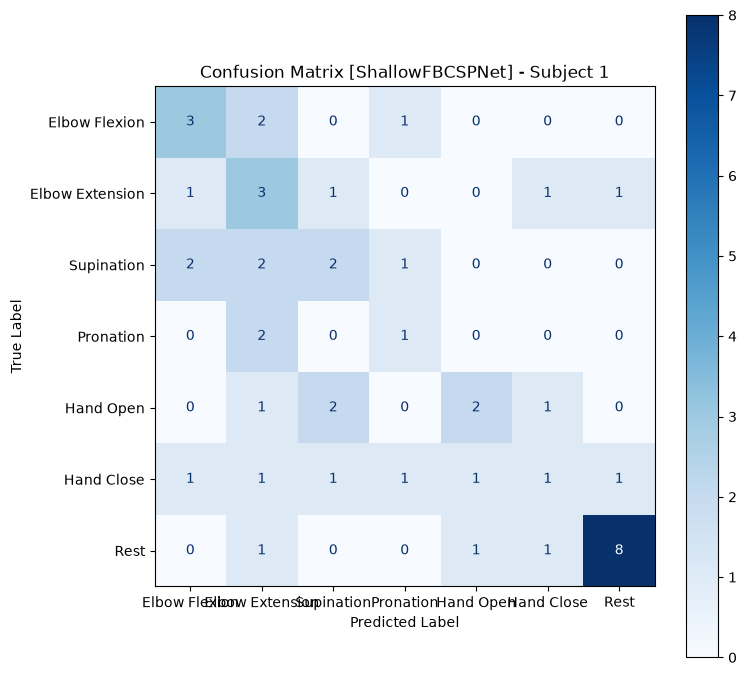

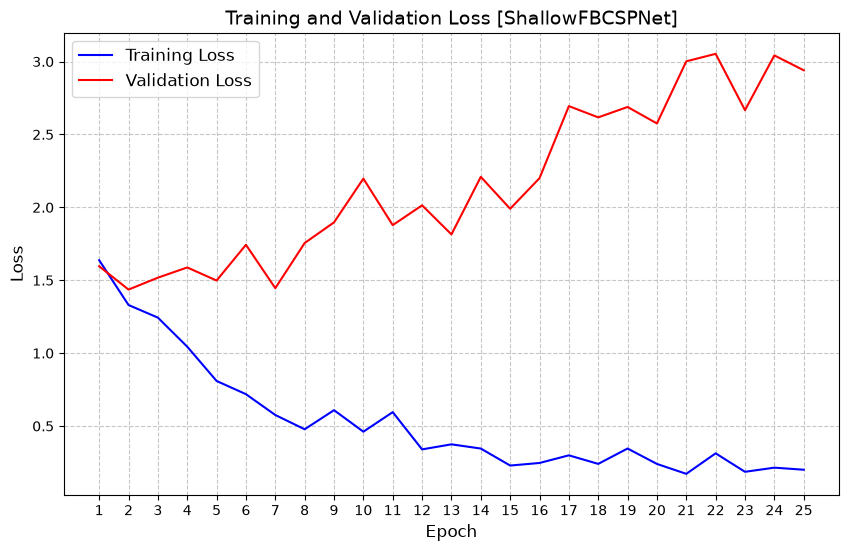

Selected Architecture: EEGNeX
Model loaded successfully from .\Models\Pretrained\EEGNeX_0.02_20.pth
Epoch#1 ==== train acc: 68.0217, train loss: 1.4664 ==== val acc: 36.9565, val loss: 1.5128
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 78.3198, train loss: 1.0548 ==== val acc: 45.6522, val loss: 1.5988
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 2)
Epoch#3 ==== train acc: 83.4688, train loss: 0.8997 ==== val acc: 34.7826, val loss: 1.9982
Epoch#4 ==== train acc: 91.3279, train loss: 0.7523 ==== val acc: 45.6522, val loss: 1.8235
Epoch#5 ==== train acc: 96.2060, train loss: 0.5638 ==== val acc: 45.6522, val loss: 1.9253
Epoch#6 ==== train acc: 95.3930, train loss: 0.5565 ==== val acc: 50.0000, val loss: 1.8290
Model saved successfully to .\Models\Subject 1\Finetuned_EEGNeX_0.01_25.pth
>>> Best m

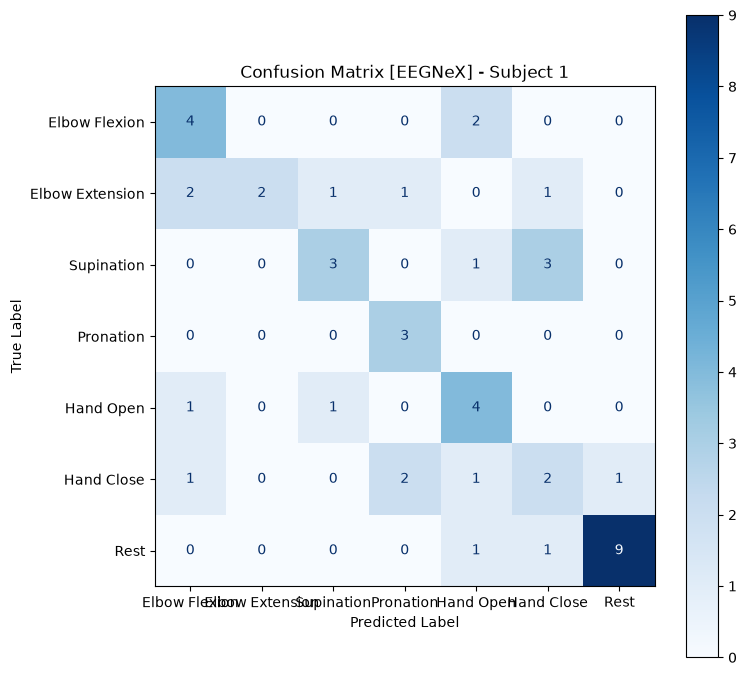

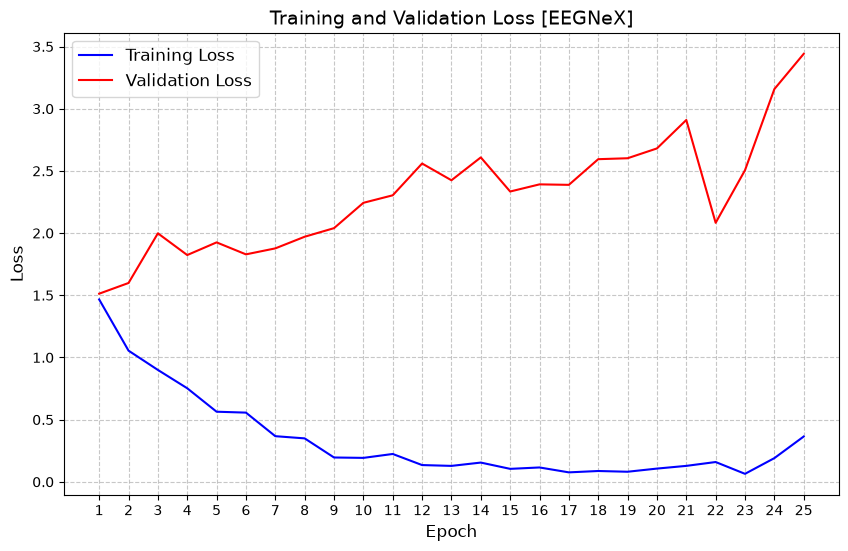

Selected Architecture: CTNet
Model loaded successfully from .\Models\Pretrained\CTNet_0.02_20.pth
Epoch#1 ==== train acc: 81.3008, train loss: 1.1908 ==== val acc: 47.8261, val loss: 1.7504
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 47.8261% (Epoch 1)
Epoch#2 ==== train acc: 94.5799, train loss: 0.6866 ==== val acc: 47.8261, val loss: 1.6856
Epoch#3 ==== train acc: 96.2060, train loss: 0.4862 ==== val acc: 54.3478, val loss: 1.5479
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model saved! Val Accuracy: 54.3478% (Epoch 3)
Epoch#4 ==== train acc: 97.8320, train loss: 0.3672 ==== val acc: 52.1739, val loss: 1.9114
Epoch#5 ==== train acc: 98.3740, train loss: 0.3119 ==== val acc: 54.3478, val loss: 1.7414
Epoch#6 ==== train acc: 100.0000, train loss: 0.1646 ==== val acc: 56.5217, val loss: 2.0317
Model saved successfully to .\Models\Subject 1\Finetuned_CTNet_0.01_25.pth
>>> Best model

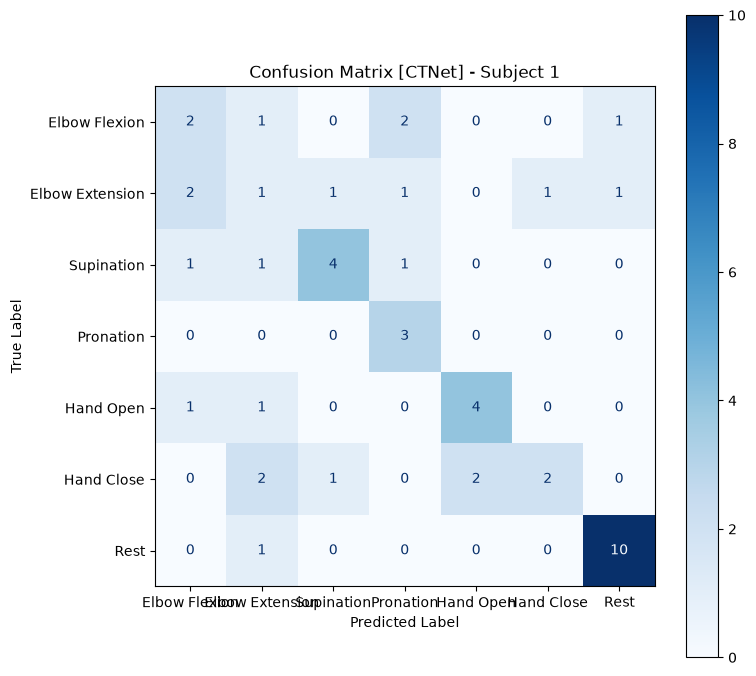

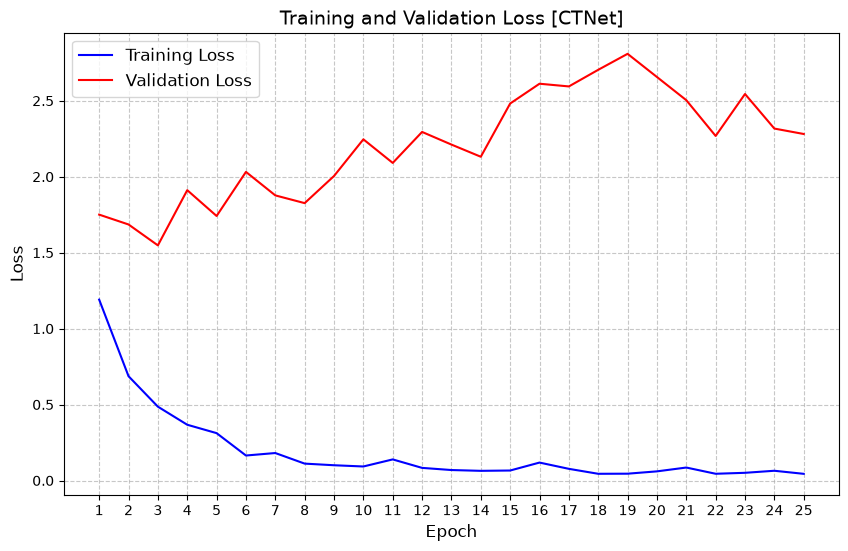

Selected Architecture: Deep4Net
Model loaded successfully from .\Models\Pretrained\Deep4Net_0.02_20.pth
Epoch#1 ==== train acc: 53.9295, train loss: 1.6248 ==== val acc: 36.9565, val loss: 1.4942
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 36.9565% (Epoch 1)
Epoch#2 ==== train acc: 53.1165, train loss: 1.3907 ==== val acc: 41.3043, val loss: 1.4476
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 41.3043% (Epoch 2)
Epoch#3 ==== train acc: 66.3957, train loss: 1.4400 ==== val acc: 45.6522, val loss: 1.2713
Model saved successfully to .\Models\Subject 1\Finetuned_Deep4Net_0.01_25.pth
>>> Best model saved! Val Accuracy: 45.6522% (Epoch 3)
Epoch#4 ==== train acc: 63.4146, train loss: 1.2734 ==== val acc: 39.1304, val loss: 1.3072
Epoch#5 ==== train acc: 66.9377, train loss: 1.2956 ==== val acc: 50.0000, val loss: 1.2985
Model saved successfully to .\Models\

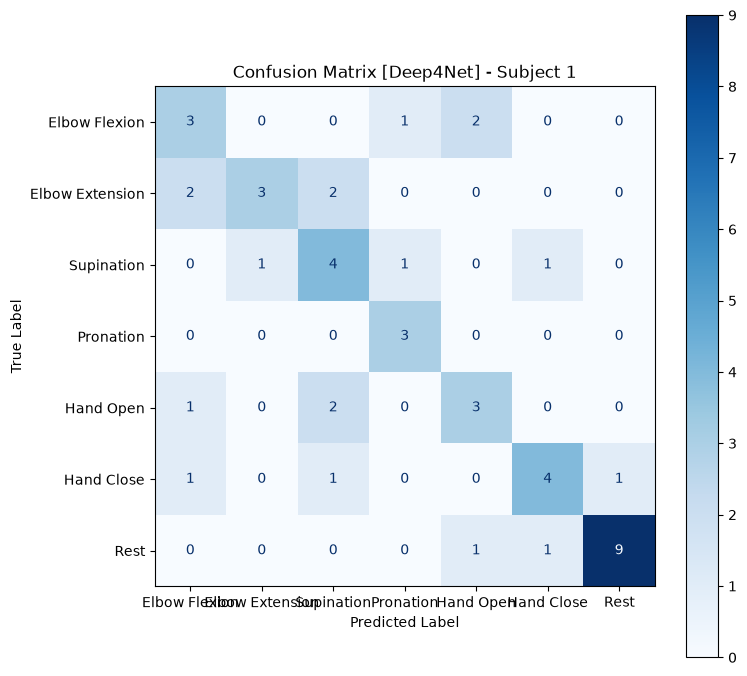

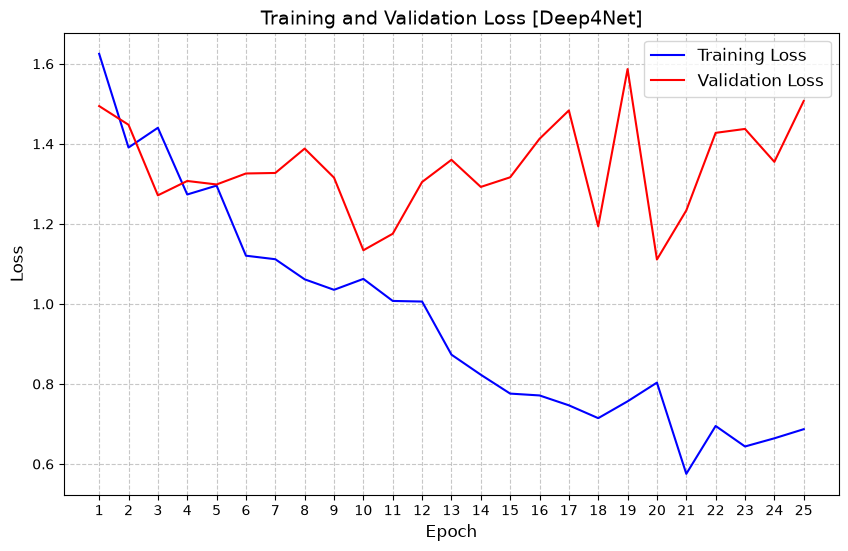

Finished training Subject 1.


In [ ]:
subject_id = 1
print(f"\n------ Setting up training for Subject {subject_id} ------")
train_loader, val_loader, test_loader = data_loader_factory.get_dataloaders(subject=subject_id, random_seed=RANDOM_SEED)


for architecture in MODEL_ARCHITECTURES:
    print('Selected Architecture:', architecture)
    model = EEGModel(
        criterion=CRITERION,
        learning_rate=LEARNING_RATE,
        architecture_key=architecture,
        random_seed=RANDOM_SEED,
        device=DEVICE
    )
    pretrained_model_path = str(MODEL_PATH + f'Pretrained\\{architecture}_{P_LEARNING_RATE}_{P_EPOCH_NUM}.pth')
    model.load_model(pretrained_model_path)
    train_loss, val_loss = [], []
    best_val_accuracy = -float('inf')
    best_epoch = 0
    best_model_path = str(MODEL_PATH + f'Subject {subject_id}\\Finetuned_{architecture}_{LEARNING_RATE}_{EPOCH_NUM}.pth')

    for epoch in range(EPOCH_NUM):
        t_loss, v_loss = model.train_one_epoch(train_loader, val_loader)
        train_loss.append(t_loss)
        val_loss.append(v_loss)
        train_acc = model.evaluate_accuracy(train_loader)
        val_acc = model.evaluate_accuracy(val_loader)
        print(
            f'Epoch#{epoch + 1} ====',
            f'train acc: {train_acc:.4f}, train loss: {t_loss:.4f} ====',
            f'val acc: {val_acc:.4f}, val loss: {v_loss:.4f}'
        )

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            best_epoch = epoch + 1
            model.save_model(best_model_path)
            print(f'>>> Best model saved! Val Accuracy: {best_val_accuracy:.4f}% (Epoch {best_epoch})')

    print('\nBest Model:')
    print(f'\tEpoch: {best_epoch}')
    print(f'\tValidation Accuracy: {best_val_accuracy:.4f}%')
    print(f'\tSaved to: {best_model_path}')

    model.load_model(best_model_path)

    print('\nModel Final Accuracy (Best Validation Model):')
    print('\tTrain:', model.evaluate_accuracy(train_loader))
    print('\tTest:', model.evaluate_accuracy(test_loader))
    print('\tValidation:', model.evaluate_accuracy(val_loader))

    visualizer.plot_confusion_matrix(
    model=model,
    data_loader=test_loader,
    class_names=classes,
    title=f'Confusion Matrix [{architecture}] - Subject {subject_id}')
    visualizer.plot_learning_curves(train_losses=train_loss, val_losses=val_loss, title_exp=f'Loss [{architecture}]')

print(f"Finished training Subject {subject_id}.")